# Pandas
- Data Analysis Library for EDA and Machine Learning
- integraded with DS and ML tools
- Helps to get the data ready for ML

## Topics to Cover
- pandas datatypes
- useful Functions
- importing and exporting data
- describing data
- viewing and selecting data
- manipulating data



In [4]:
import pandas as pd
print(pd.__version__)

3.0.3


### DataTypes
- Series - 1-dimensional
- DataFrame - 2-dimensional (more commonly used datatype)

instead of creating DataFrame we would generally import the data as ```.csv``` or ```.xlxss``` or ```URLs```

In [5]:
# Series
colors = pd.Series(['red', 'green', 'blue'])
colors

0      red
1    green
2     blue
dtype: str

### Anatomy of DataFrame
- row is referred to as axis=0
- coloumn is referede to as axis=1
- index starts at 0 by default


In [6]:
# DataFrame
car_data = {
    'car-make': ['Toyota', 'Honda', 'Ford'],
    'car-model': ['Camry', 'Civic', 'Mustang'],
    'year': [2020, 2019, 2021],
    'color': ['red', 'blue', 'black']
}

car_df = pd.DataFrame(car_data)
car_df

,car-make,car-model,year,color
0,Toyota,Camry,2020,red
1,Honda,Civic,2019,blue
2,Ford,Mustang,2021,black


In [7]:
# Importing Data from CSV
car_sales = pd.read_csv('data/car-sales.csv')
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,"$4,000.00"
1,Honda,Red,87899,4,"$5,000.00"
2,Toyota,Blue,32549,3,"$7,000.00"
3,BMW,Black,11179,5,"$22,000.00"
4,Nissan,White,213095,4,"$3,500.00"
5,Toyota,Green,99213,4,"$4,500.00"
6,Honda,Blue,45698,4,"$7,500.00"
7,Honda,Blue,54738,4,"$7,000.00"
8,Toyota,White,60000,4,"$6,250.00"
9,Nissan,White,31600,4,"$9,700.00"


## Describing Data with Pandas
- ```df.columns```      : Returns a list of column names of the DataFrame
- ```df.dtypes```       : Returns data-types information about the DataFrame
- ```df.describe()```   : Returns a statistical summary about the numeric columns of the DataFrame
- ```df.index```        : Reetruns a range of index

In [8]:
print(car_sales.columns) # Returns the column names of the DataFrame
print("")
print(car_sales.dtypes) # Returns the data types of each column in the DataFrame
print("")
print(car_sales.index) # Returns the index of the DataFrame
print("")
print(car_sales.describe()) # Returns a statistical summary of the DataFrame
print("")
print(car_sales.info()) # Returns a summary of the DataFrame including the data types and non-null values

Index(['Make', 'Colour', 'Odometer (KM)', 'Doors', 'Price'], dtype='str')

Make               str
Colour             str
Odometer (KM)    int64
Doors            int64
Price              str
dtype: object

RangeIndex(start=0, stop=10, step=1)

       Odometer (KM)      Doors
count      10.000000  10.000000
mean    78601.400000   4.000000
std     61983.471735   0.471405
min     11179.000000   3.000000
25%     35836.250000   4.000000
50%     57369.000000   4.000000
75%     96384.500000   4.000000
max    213095.000000   5.000000

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Make           10 non-null     str  
 1   Colour         10 non-null     str  
 2   Odometer (KM)  10 non-null     int64
 3   Doors          10 non-null     int64
 4   Price          10 non-null     str  
dtypes: int64(2), str(3)
memory usage: 532.0 bytes
None


In [9]:
# Mean of Numeric Columns
print(car_sales.mean(numeric_only=True)) # Returns the mean of the numeric columns in the DataFrame
print(car_sales['Odometer (KM)'].sum()) # Returns the sum of the 'Odometer (KM)' column

Odometer (KM)    78601.4
Doors                4.0
dtype: float64
786014


## Viewing and Selecting Data
- ```df.loc[index]``` : Returns the value at index, refers to specific label
- ```df.iloc[position]``` : Returns the value at position 


In [10]:
# print(car_sales.head())
# print(car_sales.tail())

animals = pd.Series(['cat', 'dog', None, 'rabbit'], index=[3, 6, 9, 3])
print(animals.loc[3]) # Returns the value at index 3, which is 'cat' if the index is unique, but since index 3 is duplicated, it will return both 'cat' and 'rabbit'.
print(animals.iloc[3]) # Returns the value at the 3rd position in the Series, which is 'rabbit'. 
print(animals.iloc[:3])
print('-'*50)
car_sales
print(car_sales.loc[3])
print(car_sales.iloc[3])
print(car_sales.loc[:3]) # Returns the rows from index 0 to 3 (inclusive) of the DataFrame.

3       cat
3    rabbit
dtype: str
rabbit
3    cat
6    dog
9    NaN
dtype: str
--------------------------------------------------
Make                    BMW
Colour                Black
Odometer (KM)         11179
Doors                     5
Price            $22,000.00
Name: 3, dtype: object
Make                    BMW
Colour                Black
Odometer (KM)         11179
Doors                     5
Price            $22,000.00
Name: 3, dtype: object
     Make Colour  Odometer (KM)  Doors       Price
0  Toyota  White         150043      4   $4,000.00
1   Honda    Red          87899      4   $5,000.00
2  Toyota   Blue          32549      3   $7,000.00
3     BMW  Black          11179      5  $22,000.00


In [11]:
# Selecting Columns and Boolean Indexing
car_sales[(car_sales['Make'] == 'Toyota') & (car_sales['Doors'] == 4)] # Returns the rows where the 'Make' column is 'Toyota' and the 'Doors' column is 4.

car_sales[car_sales['Odometer (KM)'] > 100000] # Returns the rows where the 'Odometer (KM)' column is greater than 100000.

# Crosstab
pd.crosstab(car_sales['Make'], car_sales['Doors']) # Returns a cross-tabulation of the 'Make' and 'Doors' columns, showing the frequency of each combination.


Doors,3,4,5
Make,,,
BMW,0,0,1
Honda,0,3,0
Nissan,0,2,0
Toyota,1,3,0


In [12]:
# Group by
car_sales.groupby(['Make']).mean(numeric_only=True) # Returns the mean of the numeric columns in the DataFrame, grouped by the 'Make' column.

car_sales[(car_sales['Make'] == 'Toyota') & (car_sales['Colour'] == 'White')].groupby(['Make']).mean(numeric_only=True)


,Odometer (KM),Doors
Make,,
Toyota,105021.5,4.0


<Axes: xlabel='Price'>

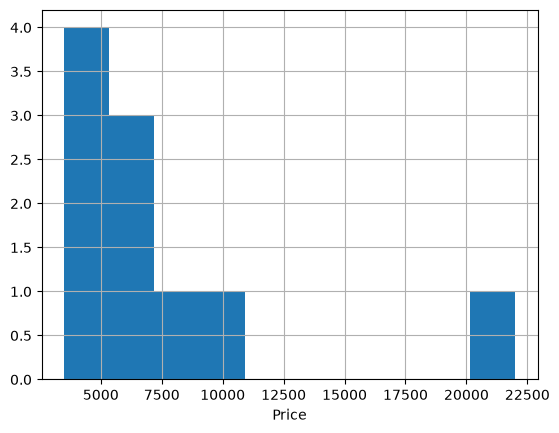

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
# car_sales['Odometer (KM)'].plot()


car_sales['Price'] = car_sales['Price'].astype(str).str.replace("['\\$','\\,',']", '', regex=True).astype(float)
plt.xlabel('Price')
car_sales['Price'].hist()


# Manipulating Data

In [14]:
type(car_sales["Make"]) # pandas.Series
car_sales["Make"].dtypes
car_sales["Make"].dtype 

car_sales["Make"] = car_sales["Make"].str.lower()


car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,toyota,White,150043,4,4000.0
1,honda,Red,87899,4,5000.0
2,toyota,Blue,32549,3,7000.0
3,bmw,Black,11179,5,22000.0
4,nissan,White,213095,4,3500.0
5,toyota,Green,99213,4,4500.0
6,honda,Blue,45698,4,7500.0
7,honda,Blue,54738,4,7000.0
8,toyota,White,60000,4,6250.0
9,nissan,White,31600,4,9700.0


In [15]:
# Missing Data
car_sales_missing = pd.read_csv('data/car-sales-missing-data.csv')
car_sales_missing


# Filling Missing Data Numerical Columns
# car_sales_missing['Odometer'] = car_sales_missing['Odometer'].fillna(car_sales_missing['Odometer'].mean(numeric_only=True))

# Droppinh NA columns
car_sales_missing_dropped = car_sales_missing.dropna(inplace=True)


car_sales_missing


,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,"$4,000"
1,Honda,Red,87899.0,4.0,"$5,000"
3,BMW,Black,11179.0,5.0,"$22,000"
4,Nissan,White,213095.0,4.0,"$3,500"


## Creating Data from existing data

In [16]:
#  Column from Series
seats_column = pd.Series([  5, 5, 5, 5, 5, 5])

# ** New column from Series
car_sales['Seats'] = seats_column
car_sales.fillna(5, inplace=True)
car_sales

# ** Column from a python list
fuel_economy = [7.5, 8.0, 6.5, 7.0, 8.5, 9.0, 7.2, 6.8, 7.9, 8.1]
car_sales['Fuel Economy Per 100 km'] = fuel_economy
car_sales

# ** Creating a column from another column
car_sales['Total Fuel Used (L)'] = car_sales['Odometer (KM)']/100 * car_sales['Fuel Economy Per 100 km']
car_sales

# ** Creating a column with a single value
car_sales['Number of Wheels'] = 4
car_sales

car_sales['Passed Road Safety'] = True
car_sales
car_sales.dtypes

Make                           str
Colour                         str
Odometer (KM)                int64
Doors                        int64
Price                      float64
Seats                      float64
Fuel Economy Per 100 km    float64
Total Fuel Used (L)        float64
Number of Wheels             int64
Passed Road Safety            bool
dtype: object

## Dropping Columns
- column is axis  = 1
- row is axis = 0 

In [17]:
car_sales.drop('Passed Road Safety', axis=1)

,Make,Colour,Odometer (KM),Doors,Price,Seats,Fuel Economy Per 100 km,Total Fuel Used (L),Number of Wheels
0,toyota,White,150043,4,4000.0,5.0,7.5,11253.225,4
1,honda,Red,87899,4,5000.0,5.0,8.0,7031.920,4
2,toyota,Blue,32549,3,7000.0,5.0,6.5,2115.685,4
3,bmw,Black,11179,5,22000.0,5.0,7.0,782.530,4
4,nissan,White,213095,4,3500.0,5.0,8.5,18113.075,4
5,toyota,Green,99213,4,4500.0,5.0,9.0,8929.170,4
6,honda,Blue,45698,4,7500.0,5.0,7.2,3290.256,4
7,honda,Blue,54738,4,7000.0,5.0,6.8,3722.184,4
8,toyota,White,60000,4,6250.0,5.0,7.9,4740.000,4
9,nissan,White,31600,4,9700.0,5.0,8.1,2559.600,4


In [18]:
# Shuffling the DataFrame
# For large datasets, shuffle only 20% of data to save time and resources. For smaller datasets, you can shuffle the entire dataset.
car_sales_shuffled = car_sales.sample(frac=1)
car_sales_shuffled
# Resetting the index of the shuffled DataFrame
car_sales_shuffled.reset_index(drop=True, inplace=True)
car_sales_shuffled

,Make,Colour,Odometer (KM),Doors,Price,Seats,Fuel Economy Per 100 km,Total Fuel Used (L),Number of Wheels,Passed Road Safety
0,nissan,White,213095,4,3500.0,5.0,8.5,18113.075,4,True
1,toyota,White,150043,4,4000.0,5.0,7.5,11253.225,4,True
2,bmw,Black,11179,5,22000.0,5.0,7.0,782.530,4,True
3,toyota,White,60000,4,6250.0,5.0,7.9,4740.000,4,True
4,toyota,Blue,32549,3,7000.0,5.0,6.5,2115.685,4,True
5,honda,Blue,54738,4,7000.0,5.0,6.8,3722.184,4,True
6,honda,Blue,45698,4,7500.0,5.0,7.2,3290.256,4,True
7,nissan,White,31600,4,9700.0,5.0,8.1,2559.600,4,True
8,honda,Red,87899,4,5000.0,5.0,8.0,7031.920,4,True
9,toyota,Green,99213,4,4500.0,5.0,9.0,8929.170,4,True


In [19]:
# applyig a function to a column
car_sales['Odometer (KM)'] = car_sales['Odometer (KM)'].apply(lambda km: km / 1.60934) # Convert KM to Miles
car_sales

,Make,Colour,Odometer (KM),Doors,Price,Seats,Fuel Economy Per 100 km,Total Fuel Used (L),Number of Wheels,Passed Road Safety
0,toyota,White,93232.629525,4,4000.0,5.0,7.5,11253.225,4,True
1,honda,Red,54618.042179,4,5000.0,5.0,8.0,7031.920,4,True
2,toyota,Blue,20225.061205,3,7000.0,5.0,6.5,2115.685,4,True
3,bmw,Black,6946.325823,5,22000.0,5.0,7.0,782.530,4,True
4,nissan,White,132411.423316,4,3500.0,5.0,8.5,18113.075,4,True
5,toyota,Green,61648.253321,4,4500.0,5.0,9.0,8929.170,4,True
6,honda,Blue,28395.491319,4,7500.0,5.0,7.2,3290.256,4,True
7,honda,Blue,34012.700859,4,7000.0,5.0,6.8,3722.184,4,True
8,toyota,White,37282.364199,4,6250.0,5.0,7.9,4740.000,4,True
9,nissan,White,19635.378478,4,9700.0,5.0,8.1,2559.600,4,True
